# 📦 Supply Prescript — Dataset Overview

**Closed-Loop Prescriptive Analytics for Supply Chain Management**

This notebook provides a visual summary of the `supply_chain_data.csv` dataset:
3,500 synthetic shipment records with physics-based delay generation used to train
the ML prediction and prescriptive optimization engine.

---


## 🔢 Quick Stats

In [ ]:
# Key dataset statistics


Dataset: 3,500 shipments · 21 features · 6 suppliers · 5 product categories

KEY STATS
─────────────────────────────────────────────
Total Shipments Delayed : 33.7%
Average Delay Days      : 1.60 days
High-Risk Shipments     : 14.2%
Worst Supplier          : TransPacific Freight
Best Supplier           : Bavaria Logistics Parts
Worst Route (avg delay) : Busan, KR → Los Angeles, US
─────────────────────────────────────────────



## 🗂️ Dataset Structure

21 columns covering every stage of a shipment lifecycle:

| Column | Type | Description |
|---|---|---|
| `supplier_name` / `supplier_tier` | categorical | Supplier identity and reliability tier (Tier 1-3) |
| `product_category` | categorical | Electronics, Automotive, Pharma, Textiles, Chemicals |
| `origin` / `destination` | categorical | Shipping route endpoints |
| `shipping_mode` | categorical | Air / Sea / Road / Rail |
| `lead_time_days` | float | Contracted lead time |
| `shipping_cost` | float | Cost per shipment (\$) |
| `supplier_delay_rate` | float | Historical supplier delay frequency (0–1) |
| `weather_risk_index` | float | Environmental risk score |
| `congestion_index` | float | Route congestion score |
| `risk_multiplier` | float | Composite risk score (key ML feature) |
| `delay_days` | float | **Target** — days delayed |
| `is_delayed` | int | **Target** — binary (1 = delayed) |


In [ ]:
# Sample rows

          supplier_name             product_category    shipping_mode  delay_days  is_delayed risk_level
   Nordic Raw Materials              Pharmaceuticals  Express Carrier         0.0           0        Low
Bavaria Logistics Parts         Industrial Machinery  Standard Ground         0.0           0        Low
   Shenzhen Silicon Ltd              Pharmaceuticals  Standard Ground         0.0           0        Low
       GlobalTech Micro Semiconductors & Electronics Ocean Intermodal         0.0           0        Low
   Apex Auto Components Semiconductors & Electronics  Standard Ground         0.0           0        Low


## 📊 Chart 1 — Delay Risk Distribution

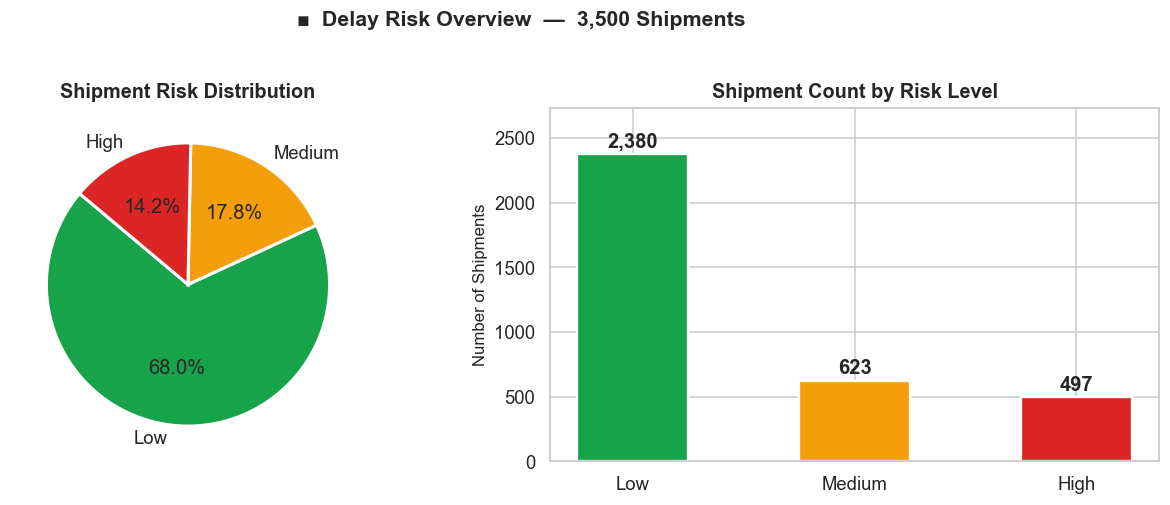

In [ ]:
# Risk distribution chart

## 📈 Chart 2 — Delay Days Distribution

Thresholds used to classify risk:
- **Low Risk**: < 2 days delayed
- **Medium Risk**: 2–5 days delayed  
- **High Risk**: > 5 days delayed


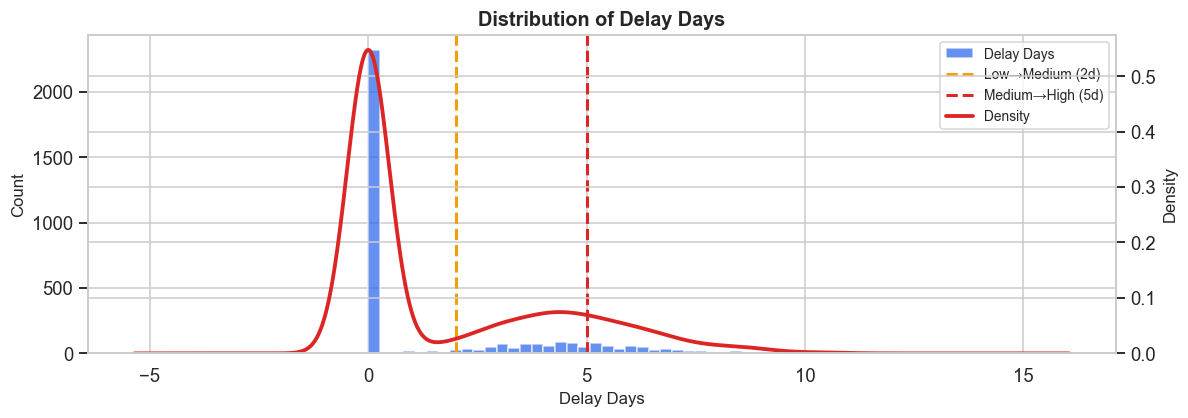

In [ ]:
# Delay days histogram

## 🏭 Chart 3 — Supplier Performance

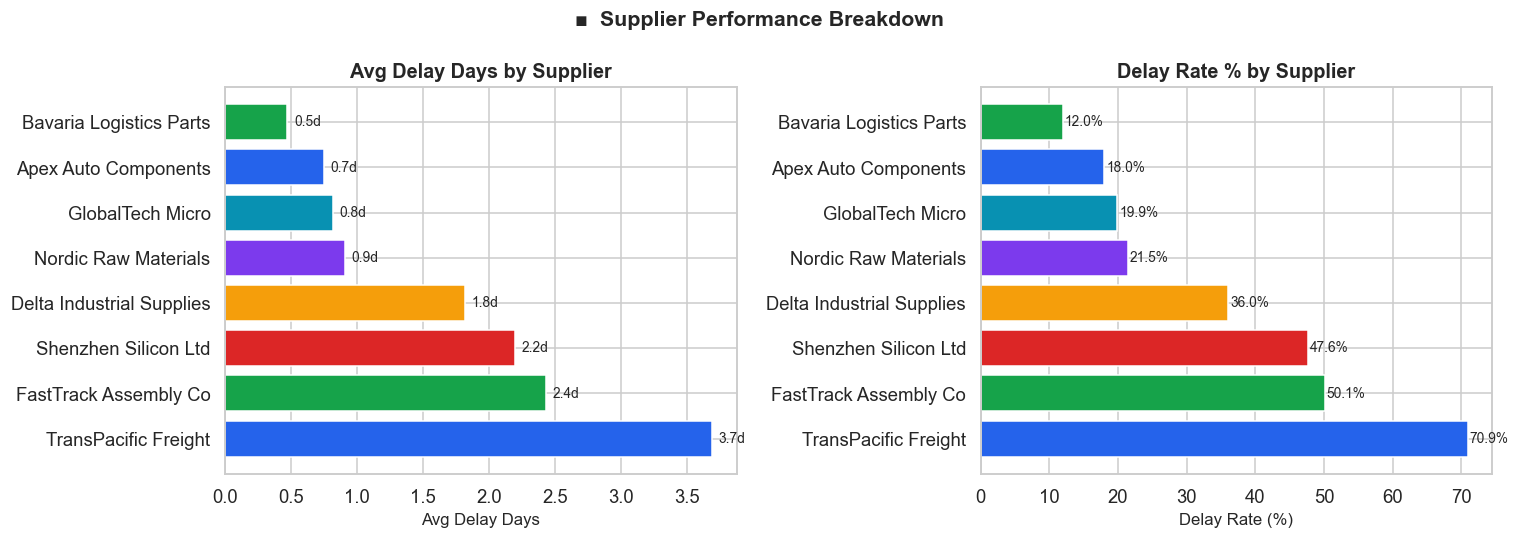

In [ ]:
# Supplier performance

## 📦 Chart 4 — Product Category & Shipping Mode

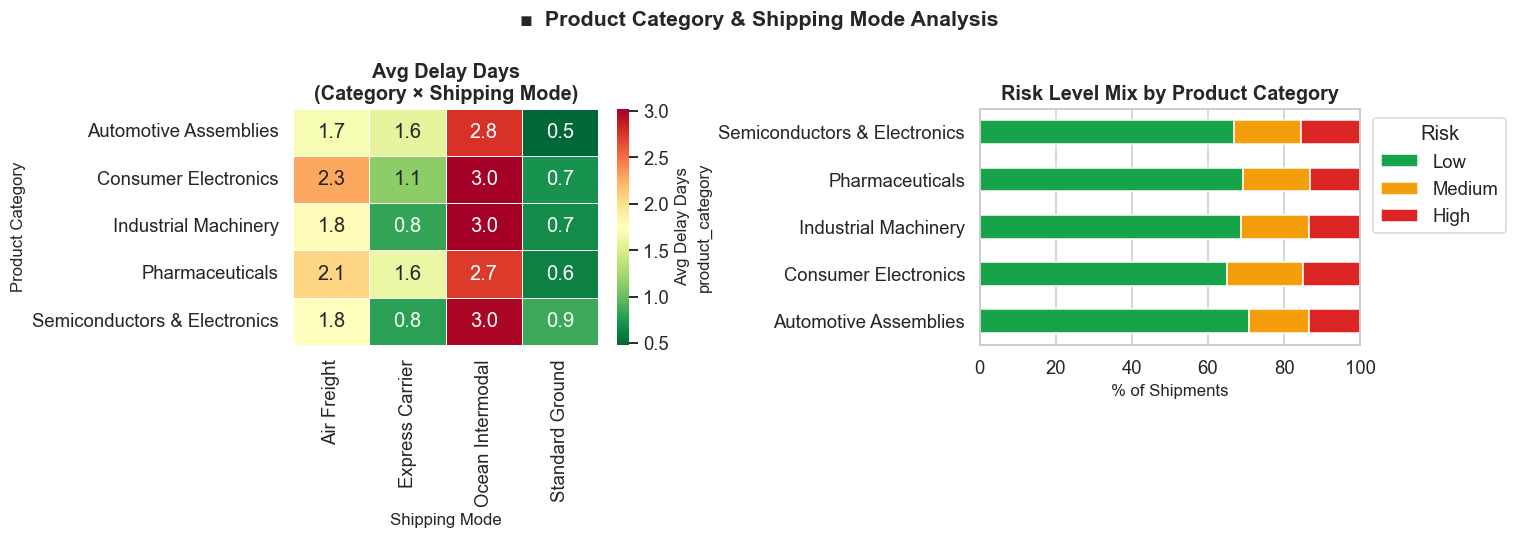

In [ ]:
# Category heatmap

## 🔍 Chart 5 — Key Risk Drivers

**`risk_multiplier`** is the strongest predictor of delay — it's a composite score
combining supplier delay rate, weather risk, and congestion index.


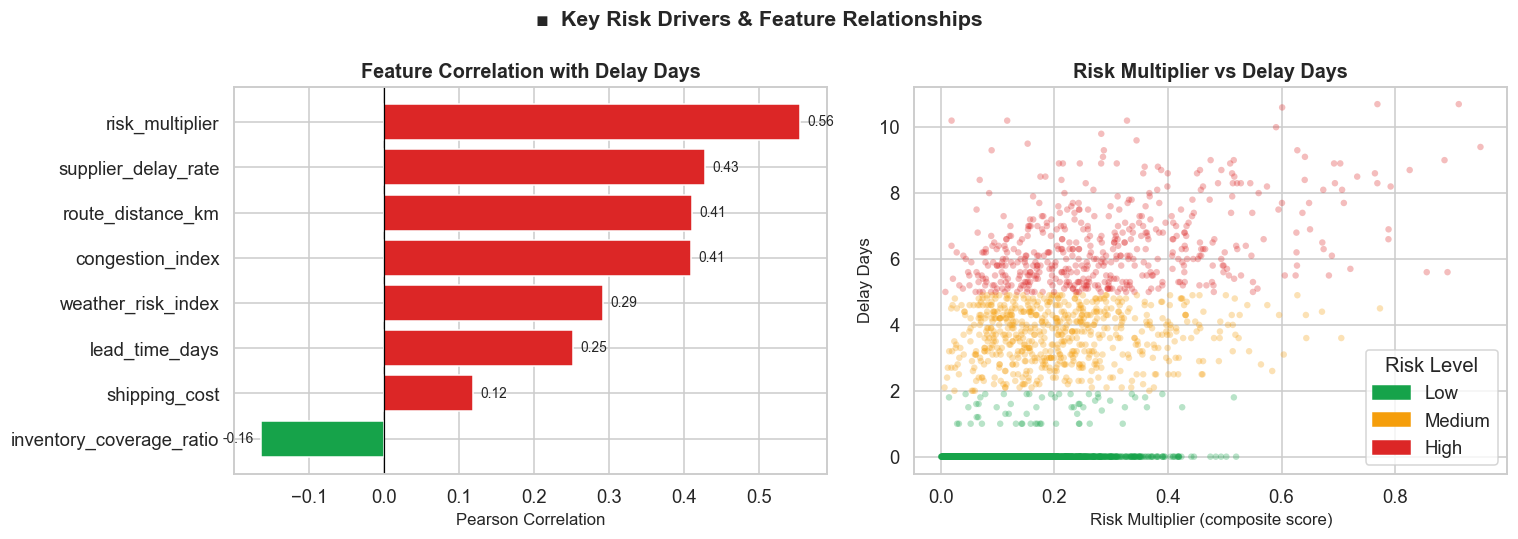

In [ ]:
# Risk drivers

## 🗺️ Chart 6 — Route Analysis (Top 12 by Avg Delay)

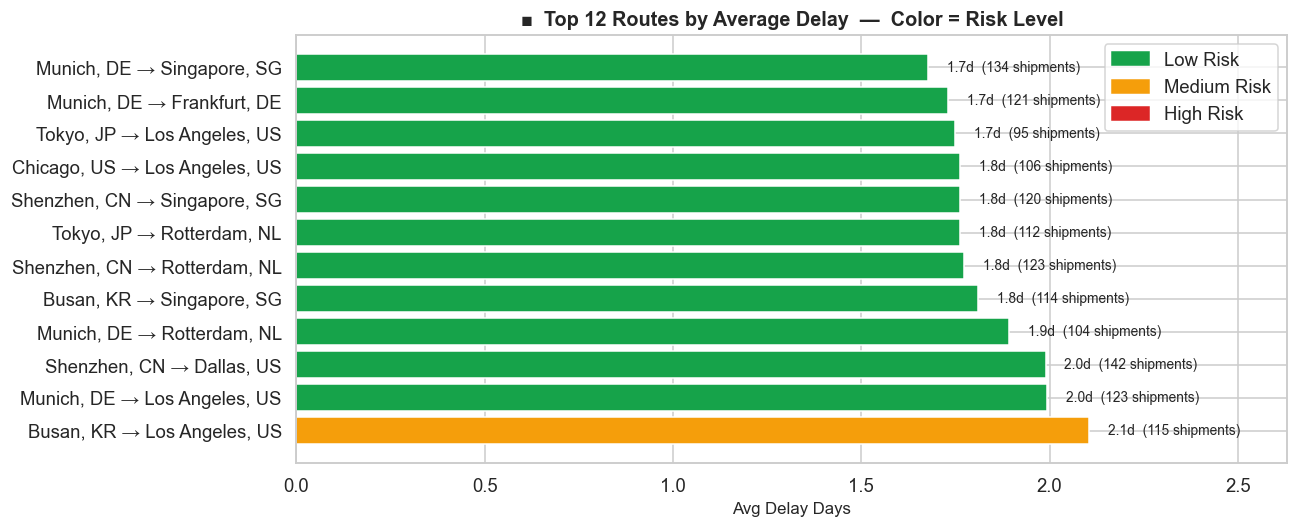

In [ ]:
# Route analysis

---
## 🤖 How This Data Feeds the ML Model

```
supply_chain_data.csv
        │
        ▼
  ColumnTransformer
  (encode categoricals, scale numerics)
        │
        ├──▶  XGBoost Classifier  →  is_delayed (96.1% accuracy, 0.996 AUC)
        │
        └──▶  XGBoost Regressor   →  delay_days (MAE 0.67, R² 0.82)
                                           │
                                           ▼
                              PuLP MILP Optimizer
                         (generates 3 feasible actions)
                                           │
                                           ▼
                              Closed-Loop Evaluator
                           (tracks decision outcomes)
```

**Top ML features (by XGBoost importance):**
1. `risk_multiplier` — composite delay risk score
2. `supplier_delay_rate` — historical supplier reliability
3. `congestion_index` — route congestion
4. `weather_risk_index` — environmental conditions
5. `lead_time_days` — contracted timeline
